## **Chapter 12**


## `PyTorch`



- **Neural Netowrks(NNs)**
- `PyTorch`는 딥 러닝을 위한 편의 wrapper를 포함하여 머신 러닝 알고리즘을 구현하고 실행하기 위한 **확장 가능한 다중 플랫폼 프로그래밍 인터페이스**이다. 
- 학계와 산업계의 많은 머신러닝 연구자와 실무자들은 딥러닝을 개발하기 위해 `PyTorch`를 채택했다. 

## **Tensors**



`torch.tensor`, `torch.from_numpy` : *목록 또는 NumPy 배열*에서 **Tensor**를 간단하게 생성

In [1]:
import torch
import numpy as np
a = [1, 2, 3]
b = np.array([4, 5, 6], dtype=np.int32)

t_a = torch.tensor(a) # 리스트 -> 텐서
t_b = torch.from_numpy(b) # 넘파이 어레이 -> 텐서

print(t_a)
print(t_b)

tensor([1, 2, 3])
tensor([4, 5, 6], dtype=torch.int32)


In [2]:
torch.is_tensor(a), torch.is_tensor(t_a) # 텐서 확인

(False, True)

In [3]:
t_ones = torch.ones(2, 3) # shape = (2, 3) -> 1로 채움

t_ones.shape

torch.Size([2, 3])

In [4]:
print(t_ones)

tensor([[1., 1., 1.],
        [1., 1., 1.]])


In [5]:
rand_tensor = torch.rand(2,3) # shape(2, 3) -> 난수로 채움

print(rand_tensor)

tensor([[0.8795, 0.8717, 0.5175],
        [0.1173, 0.8531, 0.9623]])


`cast`, `reshape`, `transpose`, `squeeze`의 여러 기능을 이용하여 **텐서 데이터 타입과 모형을 조작하기**

In [6]:
# torch.to -> 텐서의 데이터 유형을 원하는 유형으로 변경 가능
t_a_new = t_a.to(torch.int64)

print(t_a_new.dtype)

torch.int64


In [7]:
t = torch.rand(3, 5)

# torch.transopse -> 텐서의 모양 변경
t_tr = torch.transpose(t, 0, 1)
print(t.shape, ' --> ', t_tr.shape)

torch.Size([3, 5])  -->  torch.Size([5, 3])


In [8]:
t = torch.zeros(30)

# reshape -> 텐서의 모양을 지정한 형식으로 변경 
t_reshape = t.reshape(5, 6)

print(t_reshape.shape)

torch.Size([5, 6])


In [9]:
t = torch.zeros(1, 2, 1, 4, 1)

# 불필요한 차원 제거 (필요하지 않은 사이즈가 1인 차원 제거)
t_sqz = torch.squeeze(t, 2) 

print(t.shape, ' --> ', t_sqz.shape)

torch.Size([1, 2, 1, 4, 1])  -->  torch.Size([1, 2, 4, 1])


In [10]:
torch.manual_seed(1) # random seed 고정

t1 = 2 * torch.rand(5, 2) - 1
t2 = torch.normal(mean=0, std=1, size=(5, 2)) # 평균, 포준 편차를 세밀하게 설정하여 생성

In [11]:
print(t1)

tensor([[ 0.5153, -0.4414],
        [-0.1939,  0.4694],
        [-0.9414,  0.5997],
        [-0.2057,  0.5087],
        [ 0.1390, -0.1224]])


In [12]:
print(t2)

tensor([[ 0.8590,  0.7056],
        [-0.3406, -1.2720],
        [-1.1948,  0.0250],
        [-0.7627,  1.3969],
        [-0.3245,  0.2879]])


In [13]:
t3 = torch.multiply(t1, t2) # 곱셈
print(t3)

tensor([[ 0.4426, -0.3114],
        [ 0.0660, -0.5970],
        [ 1.1249,  0.0150],
        [ 0.1569,  0.7107],
        [-0.0451, -0.0352]])


In [14]:
t4 = torch.mean(t1, axis=0) # 평균 
print(t4)

tensor([-0.1373,  0.2028])


In [15]:
t5 = torch.matmul(t1, torch.transpose(t2, 0, 1)) # 행렬 곱 

print(t5)

tensor([[ 0.1312,  0.3860, -0.6267, -1.0096, -0.2943],
        [ 0.1647, -0.5310,  0.2434,  0.8035,  0.1980],
        [-0.3855, -0.4422,  1.1399,  1.5558,  0.4781],
        [ 0.1822, -0.5771,  0.2585,  0.8676,  0.2132],
        [ 0.0330,  0.1084, -0.1692, -0.2771, -0.0804]])


In [16]:
t6 = torch.matmul(torch.transpose(t1, 0, 1), t2)

print(t6)

tensor([[ 1.7453,  0.3392],
        [-1.6038, -0.2180]])


In [17]:
# 텐서의 표준계산 
norm_t1 = torch.linalg.norm(t1, ord=2, dim=1) # L2 계산

print(norm_t1)

tensor([0.6785, 0.5078, 1.1162, 0.5488, 0.1853])


In [18]:
# 위의 코드와 비교 
np.sqrt(np.sum(np.square(t1.numpy()), axis=1))

array([0.67846215, 0.5078282 , 1.1162277 , 0.5487652 , 0.18525197],
      dtype=float32)

In [19]:
torch.manual_seed(1)

t = torch.rand(6)

print(t)

t_splits = torch.chunk(t, 3) # torch.chunk(input, n = (몇개로 쪼갤지 설정), dim = (어떤 차원에 적용할지))

print(t_splits)

[item.numpy() for item in t_splits]

tensor([0.7576, 0.2793, 0.4031, 0.7347, 0.0293, 0.7999])
(tensor([0.7576, 0.2793]), tensor([0.4031, 0.7347]), tensor([0.0293, 0.7999]))


[array([0.7576316 , 0.27931088], dtype=float32),
 array([0.40306926, 0.73468447], dtype=float32),
 array([0.02928156, 0.7998586 ], dtype=float32)]

In [20]:
torch.manual_seed(1)
t = torch.rand(5)

print(t)

t_splits = torch.split(t, split_size_or_sections=[3, 2]) # split_size_or_sections =  분할될 모형 
 
[item.numpy() for item in t_splits]

tensor([0.7576, 0.2793, 0.4031, 0.7347, 0.0293])


[array([0.7576316 , 0.27931088, 0.40306926], dtype=float32),
 array([0.73468447, 0.02928156], dtype=float32)]

In [21]:
A = torch.ones(3)
B = torch.zeros(2)

C = torch.cat([A, B], axis=0) # 합치기
print(C)

tensor([1., 1., 1., 0., 0.])


In [22]:
A = torch.ones(3)
B = torch.zeros(3)

S = torch.stack([A, B], axis=1) # 쌓기
print(S)

tensor([[1., 0.],
        [1., 0.],
        [1., 0.]])


데이터가 텐서 형태, 리스트, Numpy로 존재한다면, `torch.utils.data.DataLoader()` 클래스를 사용하여 **dataset loader**로 만들 수 있다. 
- **입력 데이터 세트의 개별 요소를 반복**하는데 사용할 수 있는 `DataLoader 클래스`의 개체를 반환한다 :  `Iterator`

In [23]:
from torch.utils.data import DataLoader

t = torch.arange(6, dtype=torch.float32) 
data_loader = DataLoader(t)

In [24]:
for item in data_loader:
    print(item)

tensor([0.])
tensor([1.])
tensor([2.])
tensor([3.])
tensor([4.])
tensor([5.])


In [25]:
data_loader = DataLoader(t, batch_size=3, drop_last=False)

for i, batch in enumerate(data_loader, 1): # enumerate -> 인덱스, 원소
    print(f'batch {i}:', batch)

batch 1: tensor([0., 1., 2.])
batch 2: tensor([3., 4., 5.])


In [26]:
torch.manual_seed(1)
t_x = torch.rand([4,3], dtype=torch.float32)
t_y = torch.arange(4)

In [27]:
# 두 개의 텐서로 공동 데이터 세트 생성 
from torch.utils.data import Dataset

class JointDataset(Dataset):
    def __init__(self, x, y):
        self.x = x
        self.y = y
    def __len__(self):
        return len(self.x)
    def __getitem__(self, idx): # 지정된 인덱스로 해당 샘플 반환
        return self.x[idx], self.y[idx]

In [28]:
torch.manual_seed(1)

t_x = torch.rand([4, 3], dtype=torch.float32)
t_y = torch.arange(4)

print(t_x)
print(t_y)

tensor([[0.7576, 0.2793, 0.4031],
        [0.7347, 0.0293, 0.7999],
        [0.3971, 0.7544, 0.5695],
        [0.4388, 0.6387, 0.5247]])
tensor([0, 1, 2, 3])


In [29]:
joint_dataset = JointDataset(t_x, t_y)
for example in joint_dataset:
    print('  x: ', example[0], '  y: ', example[1])

  x:  tensor([0.7576, 0.2793, 0.4031])   y:  tensor(0)
  x:  tensor([0.7347, 0.0293, 0.7999])   y:  tensor(1)
  x:  tensor([0.3971, 0.7544, 0.5695])   y:  tensor(2)
  x:  tensor([0.4388, 0.6387, 0.5247])   y:  tensor(3)


In [30]:
# 자체 정의 데이터 세트 클래스인 'JointDataset'을 사용하는 대신 공동 데이터 세트 사용
from torch.utils.data import TensorDataset
joint_dataset = TensorDataset(t_x, t_y)

for example in joint_dataset:
    print('  x: ', example[0], '  y: ', example[1])

  x:  tensor([0.7576, 0.2793, 0.4031])   y:  tensor(0)
  x:  tensor([0.7347, 0.0293, 0.7999])   y:  tensor(1)
  x:  tensor([0.3971, 0.7544, 0.5695])   y:  tensor(2)
  x:  tensor([0.4388, 0.6387, 0.5247])   y:  tensor(3)


In [31]:
torch.manual_seed(1)
data_loader = DataLoader(dataset=joint_dataset, batch_size=2, shuffle=True)

for i, batch in enumerate(data_loader, 1):
        print(f'batch {i}:', 'x:', batch[0], 
              '\n         y:', batch[1])
        
for epoch in range(2):
    print(f'epoch {epoch+1}')
    for i, batch in enumerate(data_loader, 1):
        print(f'batch {i}:', 'x:', batch[0], 
              '\n         y:', batch[1])

batch 1: x: tensor([[0.3971, 0.7544, 0.5695],
        [0.7576, 0.2793, 0.4031]]) 
         y: tensor([2, 0])
batch 2: x: tensor([[0.7347, 0.0293, 0.7999],
        [0.4388, 0.6387, 0.5247]]) 
         y: tensor([1, 3])
epoch 1
batch 1: x: tensor([[0.7576, 0.2793, 0.4031],
        [0.3971, 0.7544, 0.5695]]) 
         y: tensor([0, 2])
batch 2: x: tensor([[0.7347, 0.0293, 0.7999],
        [0.4388, 0.6387, 0.5247]]) 
         y: tensor([1, 3])
epoch 2
batch 1: x: tensor([[0.4388, 0.6387, 0.5247],
        [0.3971, 0.7544, 0.5695]]) 
         y: tensor([3, 2])
batch 2: x: tensor([[0.7576, 0.2793, 0.4031],
        [0.7347, 0.0293, 0.7999]]) 
         y: tensor([0, 1])


In [32]:
import pathlib

imgdir_path = pathlib.Path('/content/')

file_list = sorted([str(path) for path in imgdir_path.glob('*.jpg')]) # glob : 해당 파일 나열

print(file_list)

['/content/cat-01.jpg', '/content/cat-02.jpg', '/content/cat-03.jpg', '/content/dog-01.jpg', '/content/dog-02.jpg', '/content/dog-03.jpg']


Image shape:  (900, 1200, 3)
Image shape:  (900, 1200, 3)
Image shape:  (900, 742, 3)
Image shape:  (800, 1200, 3)
Image shape:  (800, 1200, 3)
Image shape:  (900, 1200, 3)


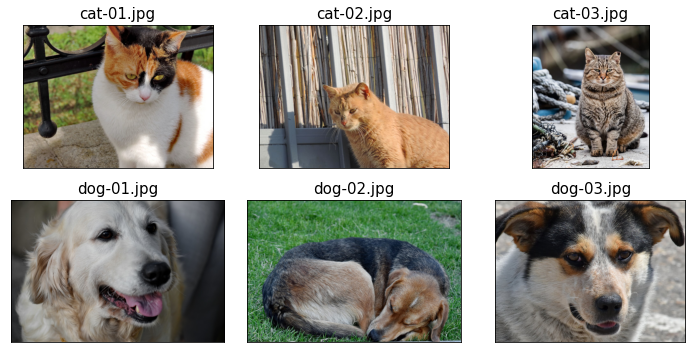

In [33]:
import matplotlib.pyplot as plt
import os
from PIL import Image

fig = plt.figure(figsize=(10, 5))
for i, file in enumerate(file_list):
    img = Image.open(file)
    print('Image shape: ', np.array(img).shape)
    ax = fig.add_subplot(2, 3, i+1) # 2x3의 i+1번째(1~6) 요소 
    ax.set_xticks([]); ax.set_yticks([])
    ax.imshow(img)
    ax.set_title(os.path.basename(file), size=15)
    
plt.tight_layout()
plt.show()

In [34]:
labels = [1 if 'dog' in os.path.basename(file) else 0 for file in file_list]
print(labels)

[0, 0, 0, 1, 1, 1]


In [35]:
class ImageDataset(Dataset):
    def __init__(self, file_list, labels):
        self.file_list = file_list
        self.labels = labels

    def __getitem__(self, index):
        file = self.file_list[index]      
        label = self.labels[index]
        return file, label

    def __len__(self):
        return len(self.labels)
    
image_dataset = ImageDataset(file_list, labels)

for file, label in image_dataset:
    print(file, label)

/content/cat-01.jpg 0
/content/cat-02.jpg 0
/content/cat-03.jpg 0
/content/dog-01.jpg 1
/content/dog-02.jpg 1
/content/dog-03.jpg 1


In [36]:
# 데이터 세트에 변환을 적용 -> 원래 콘텐츠를 디코딩한 다음 원하는 크기로 조정 
# transform 모듈을 사용하여 크기를 조정하고 로드된 픽셀을 텐서로 변환
import torchvision.transforms as transforms

class ImageDataset(Dataset):
    def __init__(self, file_list, labels, transform=None):
        self.file_list = file_list
        self.labels = labels
        self.transform = transform

    def __getitem__(self, index):
        img = Image.open(self.file_list[index])        
        if self.transform is not None:
            img = self.transform(img)
        label = self.labels[index]
        return img, label

    def __len__(self):
        return len(self.labels)

img_height, img_width = 80, 120
    
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((img_height, img_width)),
])
    
image_dataset = ImageDataset(file_list, labels, transform)

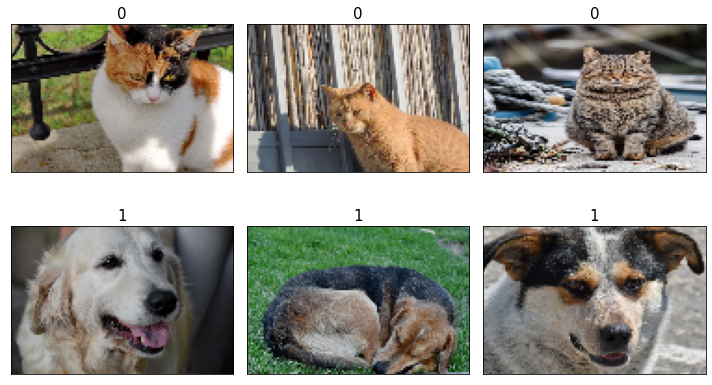

In [37]:
fig = plt.figure(figsize=(10, 6))
for i, example in enumerate(image_dataset):
    ax = fig.add_subplot(2, 3, i+1)
    ax.set_xticks([]); ax.set_yticks([])
    ax.imshow(example[0].numpy().transpose((1, 2, 0)))
    ax.set_title(f'{example[1]}', size=15)
    
plt.tight_layout()
plt.show()

In [38]:
import torchvision
from itertools import islice
image_path = './'

mnist_dataset = torchvision.datasets.MNIST(image_path, 'train', download=True)
assert isinstance(mnist_dataset, torch.utils.data.Dataset) # 데이터형 확인 

example = next(iter(mnist_dataset)) # 데이터 접근 
print(example)

  0%|          | 0/9912422 [00:00<?, ?it/s]

Extracting ./MNIST/raw/train-images-idx3-ubyte.gz to ./MNIST/raw



  0%|          | 0/28881 [00:00<?, ?it/s]

Extracting ./MNIST/raw/train-labels-idx1-ubyte.gz to ./MNIST/raw



  0%|          | 0/1648877 [00:00<?, ?it/s]

Extracting ./MNIST/raw/t10k-images-idx3-ubyte.gz to ./MNIST/raw



  0%|          | 0/4542 [00:00<?, ?it/s]

Extracting ./MNIST/raw/t10k-labels-idx1-ubyte.gz to ./MNIST/raw

(<PIL.Image.Image image mode=L size=28x28 at 0x7F38A7228B90>, 5)


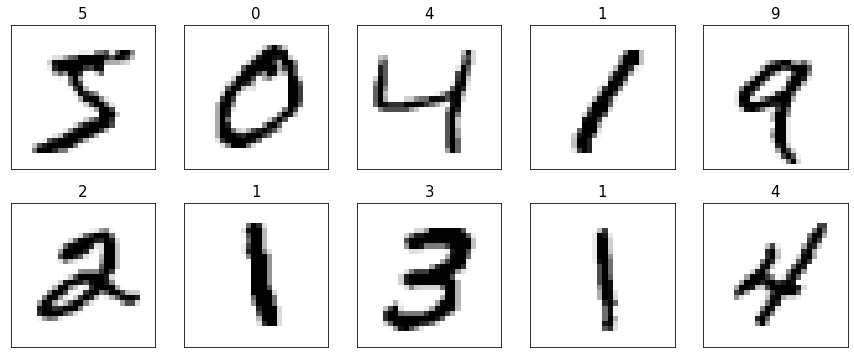

In [39]:
fig = plt.figure(figsize=(15, 6))
for i, (image, label) in islice(enumerate(mnist_dataset), 10) : # 반복 가능한 객체에서 '10번째' 안으로 자르기
    ax = fig.add_subplot(2, 5, i+1)
    ax.set_xticks([]); ax.set_yticks([])
    ax.imshow(image, cmap="gray_r")
    ax.set_title(f"{label}", size=15)
plt.show()

In [40]:
import torch
import numpy as np
import matplotlib.pyplot as plt

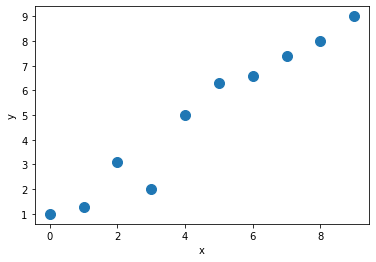

In [41]:
# 선형 회귀 모델
X_train = np.arange(10, dtype='float32').reshape((10, 1))
y_train = np.array([1.0, 1.3, 3.1, 2.0, 5.0, 6.3, 6.6, 7.4, 8.0, 9.0], dtype='float32')

plt.plot(X_train, y_train, 'o', markersize=10) # 그래프
plt.xlabel('x')
plt.ylabel('y')

plt.show()

In [42]:
# 표준화
# 데이터가 텐서 형태, 리스트, Numpy로 존재한다면, torch.utils.data.DataLoader() 클래스를 사용하여 dataset loader로 만들 수 있다.
# 입력 데이터 세트의 개별 요소를 반복하는데 사용할 수 있는 DataLoader 클래스의 개체를 반환한다 : Iterator
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

X_train_norm = (X_train - np.mean(X_train)) / np.std(X_train)
X_train_norm = torch.from_numpy(X_train_norm) # 텐서로 변환

y_train = torch.from_numpy(y_train).float()

train_ds = TensorDataset(X_train_norm, y_train)

batch_size = 1 # DataLoader의 배치 크기 설정 ->  10/1번의 반복
train_dl = DataLoader(train_ds, batch_size, shuffle=True)

이제 **선형 회귀 분석**을 위한 모델을 $z = wx + b$로 정의할 수 있다. 

여기, 우리는 `torch.nn 모듈`를 사용할 것이다.

**복잡한 NN 모델을 구축**하기 위해 **미리 정의된 레이어**를 제공한다. 

In [43]:
# 선형 회귀 모델 정의 -> 모델, 무게, 편향의 매개 변수 정의 -> 가중치와 편향 매개 변수에 해당
torch.manual_seed(1)

# 가중치 -> 자동 미분 
weight = torch.randn(1)
weight.requires_grad_()

# 편향 -> 자동 미분 : requires_grad 
bias = torch.zeros(1, requires_grad=True)

# model() 함수 정의 -> 선형 회귀
def model(xb): # @ : 행렬의 곱산 -> 입력 데이터를 사용하여 출력을 생성하는 방법 결정
    return xb @ weight + bias

# 모델 정의 후, 최적의 모델 가중치를 찾기 위해 최소화하고자 하는 손실 함수 정의
# 평균제곱오차(MSE)
def loss_fn(input, target):
    return (input-target).pow(2).mean() # MSE

# 학습 속도 설정, 200 epoch 동안 모델 훈련
# 데이터 세트의 batched version에 대해 모델 훈련
learning_rate = 0.001
num_epochs = 200
log_epochs = 10

for epoch in range(num_epochs):
    for x_batch, y_batch in train_dl:
        pred = model(x_batch) # 예측
        loss = loss_fn(pred, y_batch) # MSE loss를 사용한 미분 계산 
        loss.backward() # 변화도 

        # autograd engine를 비활성화 시켜 필요한 메모리를 줄여주고 연산속도를 증가
        # 변화도를 추적하지 않음 
        with torch.no_grad(): 
            weight -= weight.grad * learning_rate
            bias -= bias.grad * learning_rate
            weight.grad.zero_()
            bias.grad.zero_()
 
    if epoch % log_epochs==0:
        print(f'Epoch {epoch}  Loss {loss.item():.4f}')
 

Epoch 0  Loss 45.0782
Epoch 10  Loss 26.4366
Epoch 20  Loss 1.5918
Epoch 30  Loss 14.1307
Epoch 40  Loss 11.6038
Epoch 50  Loss 6.3084
Epoch 60  Loss 0.6349
Epoch 70  Loss 3.1374
Epoch 80  Loss 1.9999
Epoch 90  Loss 0.3133
Epoch 100  Loss 0.7653
Epoch 110  Loss 1.0039
Epoch 120  Loss 0.0235
Epoch 130  Loss 0.5176
Epoch 140  Loss 0.0759
Epoch 150  Loss 1.8789
Epoch 160  Loss 0.0008
Epoch 170  Loss 0.0866
Epoch 180  Loss 0.0646
Epoch 190  Loss 0.0011


Final Parameters: 2.6696107387542725 4.879678249359131


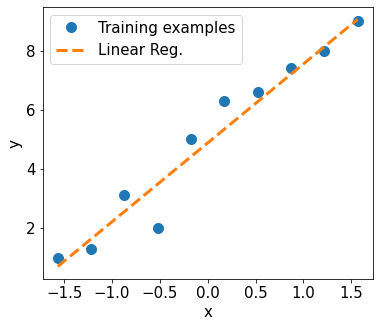

In [44]:
print('Final Parameters:', weight.item(), bias.item())
 
X_test = np.linspace(0, 9, num=100, dtype='float32').reshape(-1, 1)
X_test_norm = (X_test - np.mean(X_train)) / np.std(X_train)
X_test_norm = torch.from_numpy(X_test_norm)
y_pred = model(X_test_norm).detach().numpy()


fig = plt.figure(figsize=(13, 5))
ax = fig.add_subplot(1, 2, 1)
plt.plot(X_train_norm, y_train, 'o', markersize=10)
plt.plot(X_test_norm, y_pred, '--', lw=3)
plt.legend(['Training examples', 'Linear Reg.'], fontsize=15)
ax.set_xlabel('x', size=15)
ax.set_ylabel('y', size=15)
ax.tick_params(axis='both', which='major', labelsize=15)

plt.show()

모델의 가중지 매개변수를 학습하기 위해, **확률적 경사 강하 절차**를 사용하지만, 최적화 패키지인 `otrch.optim.SGD` 방법을 사용하여 동일한 작업을 수행할 수 있다.

*이전 예에서, **사용자 정의 손실 함수 `loss_fn`** 을 작성*하고, *확률적 경사 하강 최적화를 적용*하여 모델을 훈련시켰으나, **손실 함수**와 **그레이디언드 업데이트 작성**은 여러 프로젝트에서 반복 가능한 작업이 될 수 있다.

___

`torch.nn`모듈은 손실 함수의 집합을 제공한다.

`torch.optim`은 계산된 그레이디언트를 기반으로 매개 변수를 업데이트 하기 위해 호출할 수 있는 가장 일반적으로 사용되는 최적화 알고리즘을 지원한다.

In [45]:
import torch.nn as nn

loss_fn = nn.MSELoss(reduction='mean') # 평균 제곱 오차

input_size = 1 # 입력층
output_size = 1 # 출력층 
model = nn.Linear(input_size, output_size)

optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

for epoch in range(num_epochs):
    for x_batch, y_batch in train_dl:
        # 예측 생성
        pred = model(x_batch)[:, 0] 

        # 손실값 계산
        loss = loss_fn(pred, y_batch)

        # grdients 계산 -> 역전파
        loss.backward()

        # gradients를 사용하여 인자 업데이트
        optimizer.step()

        # gradients를 0으로 초기화 
        optimizer.zero_grad()
        
    if epoch % log_epochs==0:
        print(f'Epoch {epoch}  Loss {loss.item():.4f}')

Epoch 0  Loss 24.6684
Epoch 10  Loss 29.1377
Epoch 20  Loss 20.9207
Epoch 30  Loss 0.1257
Epoch 40  Loss 12.4922
Epoch 50  Loss 1.7845
Epoch 60  Loss 7.6425
Epoch 70  Loss 2.5606
Epoch 80  Loss 0.0157
Epoch 90  Loss 0.7548
Epoch 100  Loss 0.8412
Epoch 110  Loss 0.4923
Epoch 120  Loss 0.0823
Epoch 130  Loss 0.0794
Epoch 140  Loss 0.0891
Epoch 150  Loss 0.0973
Epoch 160  Loss 0.1043
Epoch 170  Loss 0.1103
Epoch 180  Loss 0.0009
Epoch 190  Loss 0.0764


Final Parameters: 2.6496422290802 4.87706995010376


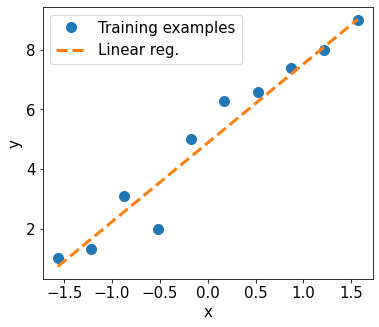

In [46]:
print('Final Parameters:', model.weight.item(), model.bias.item())
 
X_test = np.linspace(0, 9, num=100, dtype='float32').reshape(-1, 1)
X_test_norm = (X_test - np.mean(X_train)) / np.std(X_train)
X_test_norm = torch.from_numpy(X_test_norm)
y_pred = model(X_test_norm).detach().numpy()


fig = plt.figure(figsize=(13, 5))
ax = fig.add_subplot(1, 2, 1)
plt.plot(X_train_norm, y_train, 'o', markersize=10)
plt.plot(X_test_norm, y_pred, '--', lw=3)
plt.legend(['Training examples', 'Linear reg.'], fontsize=15)
ax.set_xlabel('x', size=15)
ax.set_ylabel('y', size=15)
ax.tick_params(axis='both', which='major', labelsize=15)
 
plt.show()

-이전 예제에서는 **모델을 처음부터 만드는 방법**을 확인했다.
- **확률적 경사 하강 최적화**를 사용하여 모델을 훈련시켰다.

- `PyTorch`는 NN 모델의 구성 요소로 쉽게 사용할 수 있는 `torch.nn`을 통해 **이미 정의된 레이어를 제공**한다.

**Iris 꽃 데이터 세트**를 사용하여 *분류 작업을 해결*하고, `torch.nn`을 사용하여 *2층 퍼셉트론을 구축하는 방법*에 대해 알아볼 것이다.

In [47]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split 

# 데이터 불러오기
iris = load_iris()
X = iris['data']
y = iris['target']
 
# 데이터 분류
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1./3, random_state=1)

In [48]:
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

# 표준화
X_train_norm = (X_train - np.mean(X_train)) / np.std(X_train)
X_train_norm = torch.from_numpy(X_train_norm).float()
y_train = torch.from_numpy(y_train) 

train_ds = TensorDataset(X_train_norm, y_train)

torch.manual_seed(1)
batch_size = 2
train_dl = DataLoader(train_ds, batch_size, shuffle=True)

`nn.Module` 클래스를 사용해서, 몇 개의 층을 쌓고 NN을 만들 수 있다.


*완전 연결 레이어* 또는 *밀접한 레이러라고도 달려진 선형 레이어*를 사용할 것이며, $f(w × x + b)$로 가장 잘 나타낼 수 있다.
  - x : 입력 특징을 포함하는 텐서
  - w : 가중치 행렬
  - b : 편향 벡터
  - f : 활성화 함수

**NN의 각 계층**은 이전 계층으로부터 입력을 받으므로, 그것의 차원이 고정되어 있다.

NN 아키텍처를 설계할 때만 출력의 차원에 관심을 가질 필요가 있다.

두 개의 숨겨진 레이어가 있는 모델을 정의할 것이다.
- 첫번째는 네 가지 특징을 입력받아 16개의 뉴런에 투영한다.
- 두번째 레이어는 이전 레이어의 출력을 수신하고 세 개의 출력 뉴런에 투영한다
  - 왜냐하면 세 개의 클래스 레이블을 가지고 있기 때문이다.


- **첫 번째 계층**에는 `시그모이드 활성화` 기능
- **마지막 계층**에는 `소프트맥스 활성화` 기능 사용

In [49]:
class Model(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.layer1 = nn.Linear(input_size, hidden_size)   # 입력층 뉴런 -> 은닉층 뉴런
        self.layer2 = nn.Linear(hidden_size, output_size)   # 은닉층 뉴런 -> 출력층 뉴런

    # input으로 어떤 계산을 진행하여 output이 나올지를 정의  -> 모델에서 실행되어야 하는 계산 정의
    def forward(self, x): 
        x = self.layer1(x)
        x = nn.Sigmoid()(x) # 시그모이드
        x = self.layer2(x)
        x = nn.Softmax(dim=1)(x) # 소프트맥스
        return x
    
input_size = X_train_norm.shape[1]
hidden_size = 16
output_size = 3
 
model = Model(input_size, hidden_size, output_size)

# 손실함수를 교차 엔트로피 손실로 지정하고 최적기를 Adam으로 지정
learning_rate = 0.001
loss_fn = nn.CrossEntropyLoss() 
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [50]:
# 모델 훈련
num_epochs = 100
loss_hist = [0] * num_epochs # 훈련 손실 유지
accuracy_hist = [0] * num_epochs # 훈련 정확도 유지

for epoch in range(num_epochs):
    for x_batch, y_batch in train_dl:
        pred = model(x_batch)
        loss = loss_fn(pred, y_batch) # 손실값 계산
        loss.backward() # gradinet 역전파 계산 
        optimizer.step() # 업데이트
        optimizer.zero_grad() # 초기화 
    
        loss_hist[epoch] += loss.item() * y_batch.size(0)
        is_correct = (torch.argmax(pred, dim=1) == y_batch).float() # argmax : 차원에 따라 가장 큰 값의 인덱스 반환
        accuracy_hist[epoch] += is_correct.sum()
        
    loss_hist[epoch] /= len(train_dl.dataset) # 오차
    accuracy_hist[epoch] /= len(train_dl.dataset) # 정확도

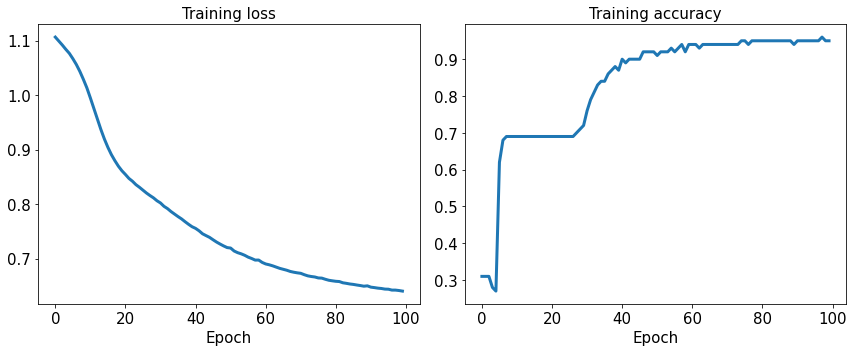

In [51]:
fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(1, 2, 1)
ax.plot(loss_hist, lw=3)
ax.set_title('Training loss', size=15)
ax.set_xlabel('Epoch', size=15)
ax.tick_params(axis='both', which='major', labelsize=15)

ax = fig.add_subplot(1, 2, 2)
ax.plot(accuracy_hist, lw=3)
ax.set_title('Training accuracy', size=15)
ax.set_xlabel('Epoch', size=15)
ax.tick_params(axis='both', which='major', labelsize=15)
plt.tight_layout()

 
plt.show()

In [52]:
# 테스트 데이터 셋의 훈련 모델의 분류 정확성 평가
# 표준화 적용
X_test_norm = (X_test - np.mean(X_train)) / np.std(X_train)
X_test_norm = torch.from_numpy(X_test_norm).float()
y_test = torch.from_numpy(y_test) 
pred_test = model(X_test_norm)

correct = (torch.argmax(pred_test, dim=1) == y_test).float()
accuracy = correct.mean()
 
print(f'Test Acc.: {accuracy:.4f}') # 98%의 분류 정확도

Test Acc.: 0.9800


In [53]:
# 저장 -> 모델 구조와 학습된 모든 매개 변수가 저장
path = 'iris_classifier.pt'
torch.save(model, path)

In [54]:
model_new = torch.load(path) # 모델을 다시 로드 -> 모델 구조와 가중치를 모두 저장한 상태 -> 매개변수를 한줄로 쉽게 재구성

model_new.eval() # dropout 및 배치 정규화를 평가모드로 설정 

Model(
  (layer1): Linear(in_features=4, out_features=16, bias=True)
  (layer2): Linear(in_features=16, out_features=3, bias=True)
)

In [55]:
# 새 모델 평가 
pred_test = model_new(X_test_norm)

correct = (torch.argmax(pred_test, dim=1) == y_test).float()
accuracy = correct.mean()
 
print(f'Test Acc.: {accuracy:.4f}') # 약 98% 정확도 -> 이전과 동일 

Test Acc.: 0.9800


In [56]:
path = 'iris_classifier_state.pt'

torch.save(model.state_dict(), path) # 학습된 매개 변수만 저장 

In [57]:
# 모델을 구성 -> 모델에 로드된 파라미터 공급 -> 저장된 매개 변수를 다시 로드 
model_new = Model(input_size, hidden_size, output_size)
model_new.load_state_dict(torch.load(path))

<All keys matched successfully>

**다층 신경 네트워크에 대한 활성화 기능 선택**

- 다층 NN을 구현하는 데 유용한 대체 비선형 함수에 대해 알아볼 것이다.
- 기술적으로, 우리는 미분 가능한 모든 기능을 **다층 NN**에 활성화 함수로 사용할 수 있다.
- 그러나 복잡한 문제를 해결할 수 있도록 **일반적인 인공 NN**에서 비선형을 도입하기 때문에, 실제로는 숨겨진 계층과 출력 계층 모두에 대해 선형 활성화 함수를 사용하는 것은 그리 유용하지 않을 것이다.
- 선형 함수의 합은 결국 선형 함수를 산출한다.

___

> `로지스틱 (sigmoid) 활성화 함수`는 아마도 뇌에서 뉴런의 개념을 가장 가깝게 모방할 것이다. 

> 우리는 그것을 뉴런이 발화하는지 여부에 대한 확률로 생각할 수 있다.

> 로지스틱 : $ σ(z) = $$1 \over (1+ e^-z) $

> 이 경우 **시그모이드 함수**의 출력이 0에 가까울 것이기 때문에, 매우 부정적인 입력을 가질 경우 **로지스틱(시그모이드 활성화 함수)**는 문제가 될 수 있다.

> 시그모이드 함수가 0에 가까운 출력을 반환하면 NN은 매우 느리게 학습하고 훈련 중에 손실 환경의 지역 최소값에 갇힐 가능성이 더 높아진다.

> 소프트맥스는 argmax 함수의 부드러운 형태의 시그모이드 함수이다.



In [58]:
import numpy as np

X = np.array([1, 1.4, 2.5])
w = np.array([0.4, 0.3, 0.5])

def net_input(X, w):
    return np.dot(X, w)

def logistic(z):
    return 1.0 / (1.0 + np.exp(-z))

def logistic_activation(X, w):
    z = net_input(X, w)
    return logistic(z)

# 순 입력을 계산하여 이러한 특정 특징 값과 가중 계수를 가진 로지스틱 뉴런을 활성화
# -> 특정 샘플 x가 양의 클래스에 속할 확률 88.8%
print(f'P(y=1|x) = {logistic_activation(X, w):.3f}') 

P(y=1|x) = 0.888


In [59]:
# W : (n_output_units, n_hidden_units+1)의 모양을 가진 어레이
# 첫 번째 열은 편향 단위
W = np.array([[1.1, 1.2, 0.8, 0.4],
              [0.2, 0.4, 1.0, 0.2],
              [0.6, 1.5, 1.2, 0.7]])

# A : (n_hidden_units+1, n_samples)의 모양을 가진 어레이
# 첫 번째 열은 1
A = np.array([[1, 0.1, 0.4, 0.6]])
Z = np.dot(W, A[0])
y_probas = logistic(Z)
print('Net Input: \n', Z)

print('Output Units:\n', y_probas) 

Net Input: 
 [1.78 0.76 1.65]
Output Units:
 [0.85569687 0.68135373 0.83889105]


출력에서 볼 수 있듯이 결과 값은 3-class 문제의 확률로 해석할 수 없다.
  - 이유는 그들의 합이 1이 되지 않기 때문이다.

그러나, 사실, 이것은 모델을 사용하여 클래스 멤버십 확률이 아닌 **클래스 레이블만 예측**한다면 큰 문제가 되지 않는다. 
  - 이전에 얻은 출력 단위에서 **클래스 레이블을 예측하는 한 가지 방법**은 `최대값`을 사용하는 것이다.

In [60]:
y_class = np.argmax(Z, axis=0) 
print('Predicted class label:', y_class) 

Predicted class label: 0


이전에 `argmax 함수`를 사용하여 **클래스 레이블**을 얻는 방법을 확인했다.

`softmax 함수`는 `argmax 함수`의 부드러운 형태이며, *단을 클래스 인덱스를 제공*하는 대신, **각 클래스의 확률**을 제공한다.

따라서, *다중 클래스 설정(다항 로지스틱 회귀 분석)*에 의미 있는 **클래스 확률을 계산**할 수 있다.

In [61]:
def softmax(z): # 소프트맥스로 계산
    return np.exp(z) / np.sum(np.exp(z))

y_probas = softmax(Z)
print('Probabilities:\n', y_probas)

np.sum(y_probas) 

Probabilities:
 [0.44668973 0.16107406 0.39223621]


1.0

예측된 클래스 확률은 예상대로 1이 된다.

예측된 클래스 레이블이 로지스틱 출력에 `argmax 함수`를 적용할 때와 같다는 점도 주목할 만하다.

`softmax 함수`의 결과를 다중 클래스 설정에서 의미있는 클래스 멤버쉽 예측을 얻는 데 유용한  **정규화된 출력으로 생각하는 데 도움**이 될 수 있다.

**다중 클래스 분류 모델을 구축**할 때 `torch.softmax()`를 사용하여 입력된 예제에 대한 **각 클래스 멤버십의 확률을 추정**할 수 있다.

`torch.softmax()` 활성화 함수를 사용할 수 있는 방법을 알아보기 위해 **Z**를 다음 코드의 텐서로 변환하고 배치 크기를 위해 추가 차원을 확보한다.

In [62]:
torch.softmax(torch.from_numpy(Z), dim=0)

tensor([0.4467, 0.1611, 0.3922], dtype=torch.float64)

**인공 NN**의 **은닉 계층**에서 자주 사용되는 또 다른 `시그모이드 함수`는 **쌍곡선 탄젠트(tanh)**은 **로지스틱 함수의 스케일링 버전으로 해석**될 수 있다.

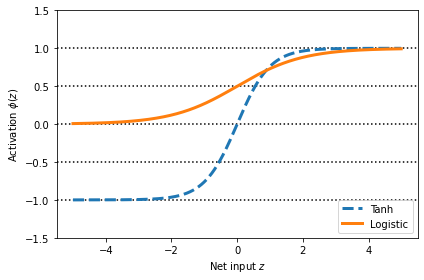

In [63]:
import matplotlib.pyplot as plt
%matplotlib inline

# tanh 함수 - 로지스틱 함수의 스케일링 버전
def tanh(z):
    e_p = np.exp(z)
    e_m = np.exp(-z)
    return (e_p - e_m) / (e_p + e_m)

z = np.arange(-5, 5, 0.005)
log_act = logistic(z)
tanh_act = tanh(z)
plt.ylim([-1.5, 1.5])
plt.xlabel('Net input $z$')
plt.ylabel('Activation $\phi(z)$')
plt.axhline(1, color='black', linestyle=':')
plt.axhline(0.5, color='black', linestyle=':')
plt.axhline(0, color='black', linestyle=':')
plt.axhline(-0.5, color='black', linestyle=':')
plt.axhline(-1, color='black', linestyle=':')
plt.plot(z, tanh_act, linewidth=3, linestyle='--', label='Tanh')
plt.plot(z, log_act, linewidth=3, label='Logistic')
plt.legend(loc='lower right')
plt.tight_layout()


plt.show()

이전 예시를 위해 `로지스틱`과 `tanh 함수`를 상세히 구현했다. 
- NumPy의 `tanh 함수`를 사용할 수 있다.
- 또는 NN 모델을 작성할 때 PyTorch에서 `torch.tanh(x)`를 사용하여 동일한 값을 얻을 수 있다. 


In [64]:
np.tanh(z)

array([-0.9999092 , -0.99990829, -0.99990737, ...,  0.99990644,
        0.99990737,  0.99990829])

In [65]:
torch.tanh(torch.from_numpy(z))

tensor([-0.9999, -0.9999, -0.9999,  ...,  0.9999,  0.9999,  0.9999],
       dtype=torch.float64)

In [66]:
from scipy.special import expit

expit(z)

array([0.00669285, 0.00672617, 0.00675966, ..., 0.99320669, 0.99324034,
       0.99327383])

In [67]:
torch.sigmoid(torch.from_numpy(z)) # sigmoid를 이용하여 동일한 계산 수행

tensor([0.0067, 0.0067, 0.0068,  ..., 0.9932, 0.9932, 0.9933],
       dtype=torch.float64)

In [68]:
torch.relu(torch.from_numpy(z))

tensor([0.0000, 0.0000, 0.0000,  ..., 4.9850, 4.9900, 4.9950],
       dtype=torch.float64)